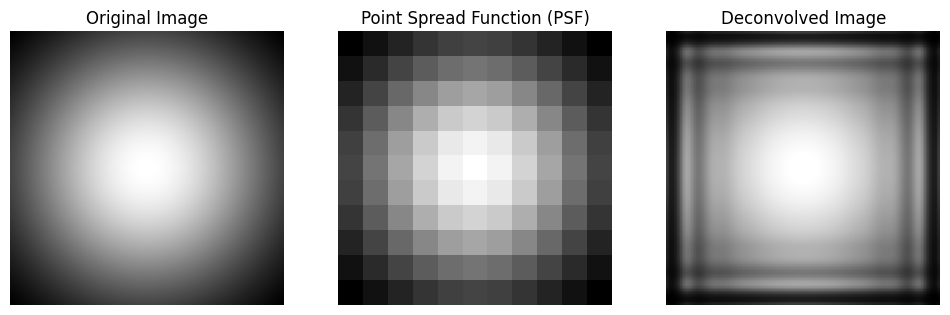

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d

def richardson_lucy(image, psf, num_iter=50):
    """
    image: 2-dimensional input, single-channel
    psf:   2-dimensional input, point spread function
    """
    pad = psf.shape[-1] // 2 + 1
    image_padded = np.pad(image, pad, mode='reflect')

    im_deconv = np.full_like(image_padded, 0.5)
    psf_mirror = np.flip(psf)

    eps = 1e-12

    for _ in range(num_iter):
        conv = convolve2d(im_deconv, psf, mode='same') + eps
        relative_blur = image_padded / conv
        im_deconv *= convolve2d(relative_blur, psf_mirror, mode='same') + eps
        im_deconv = np.clip(im_deconv, -1, 1)

    return im_deconv[pad:-pad, pad:-pad]

image = np.exp(-((np.linspace(-1, 1, 100)**2)[:, None] + (np.linspace(-1, 1, 100)**2)))

psf = np.exp(-((np.linspace(-1, 1, 11)**2)[:, None] + (np.linspace(-1, 1, 11)**2)))

psf /= psf.sum()

deconvolved_image = richardson_lucy(image, psf, num_iter=30)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(psf, cmap='gray')
plt.title('Point Spread Function (PSF)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(deconvolved_image, cmap='gray')
plt.title('Deconvolved Image')
plt.axis('off')

plt.show()


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d
from PIL import Image

def richardson_lucy(image, psf, num_iter=50):
    """
    Perform Richardson-Lucy deconvolution.
    """
    pad = psf.shape[-1] // 2 + 1
    image_padded = np.pad(image, pad, mode='reflect')
    im_deconv = np.full_like(image_padded, 0.5)
    psf_mirror = np.flip(psf)
    eps = 1e-12

    for _ in range(num_iter):
        conv = convolve2d(im_deconv, psf, mode='same') + eps
        relative_blur = image_padded / conv
        im_deconv *= convolve2d(relative_blur, psf_mirror, mode='same') + eps
        im_deconv = np.clip(im_deconv, -1, 1)

    return im_deconv[pad:-pad, pad:-pad]

def load_image(filepath):
    """
    Load an image from a file, convert to grayscale, and normalize to [0, 1].
    """
    image = Image.open(filepath).convert('L')
    image = np.array(image) / 255.0
    return image

def save_image(image, filepath):
    """
    Save an image to a file.
    """
    image = (image * 255).astype(np.uint8)
    Image.fromarray(image).save(filepath)

def add_gaussian_noise(image, mean=0, std=0.55):
    """
    Add Gaussian noise to an image.
    """
    noise = np.random.normal(mean, std, image.shape)
    noisy_image = image + noise
    return np.clip(noisy_image, 0, 1)

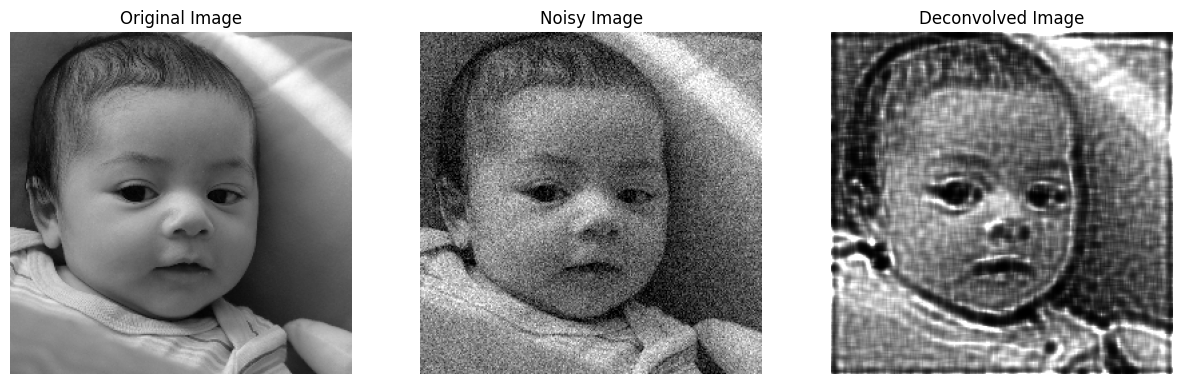

In [8]:
if __name__ == "__main__":
    image_path = 'test.png'
    image = load_image(image_path)

    noisy_image = add_gaussian_noise(image, mean=0, std=0.1)

    psf_size = 11
    psf = np.exp(-((np.linspace(-1, 1, psf_size)**2)[:, None] + (np.linspace(-1, 1, psf_size)**2)))
    psf /= psf.sum()

    num_iterations = 30
    deconvolved_image = richardson_lucy(noisy_image, psf, num_iter=num_iterations)

    output_image_path = 'deconvolved_image.jpg'
    save_image(deconvolved_image, output_image_path)

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(image, cmap='gray')
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(noisy_image, cmap='gray')
    plt.title('Noisy Image')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(deconvolved_image, cmap='gray')
    plt.title('Deconvolved Image')
    plt.axis('off')

    plt.show()